<a href="https://colab.research.google.com/github/Adhityayusuf/PCVK26_09_M.Adhitya-Yusuf-Al-Ayyubi/blob/main/Week5_Histogram_Dithering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'M.Adhitya Yusuf Al-Ayyubi'
NIM  = '244107020045'

N = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA  :', NAMA)
print('NIM   :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM:', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])


NAMA  : M.Adhitya Yusuf Al-Ayyubi
NIM   : 244107020045 | N = 45
bins   : 16
clip   : 1.0
tile   : 3
L      : 2
WAKTU : 2026-09-27 22:34:21 WIB
SISTEM: 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 4ad3f01885cb3793


## Persiapan: Mount Drive, Import Library, dan Folder Kerja

In [2]:
# Mount Google Drive (pastikan Drive berisi folder PCVK/Images dan PCVK/Images/<NIM>)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math, os, glob


In [6]:
CONTOH = '/content/drive/MyDrive/pcvk/images'          # citra contoh bersama
BASE   = '/content/drive/MyDrive/pcvk/images/' + NIM   # citra KTM milik Anda
print('CONTOH:', CONTOH)
print('BASE  :', BASE)


CONTOH: /content/drive/MyDrive/pcvk/images
BASE  : /content/drive/MyDrive/pcvk/images/244107020045


---
# E-1 PERCOBAAN HISTOGRAM


In [7]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h


### Langkah 3 — Histogram RGB
**Tahap 1**: jalankan pada `lena.jpg`, cocokkan bentuknya dengan gambar contoh pada modul.
Jika sudah cocok, lanjut ke **Tahap 2** dengan `KTM1b.jpg` milik Anda.

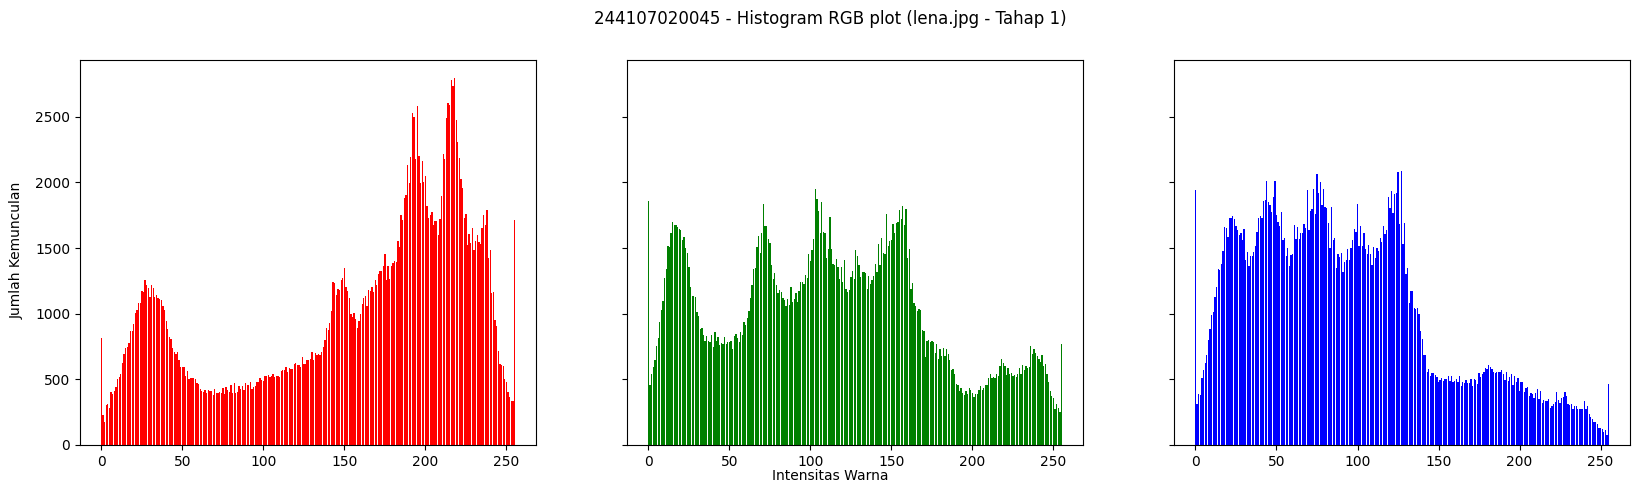

In [8]:
# ===== Tahap 1: verifikasi dengan lena.jpg =====
img = cv.imread(CONTOH + '/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

red   = histogram_manual(img[:, :, 0])
green = histogram_manual(img[:, :, 1])
blue  = histogram_manual(img[:, :, 2])

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot (lena.jpg - Tahap 1)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red,   color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue,  color='blue')
plt.show()


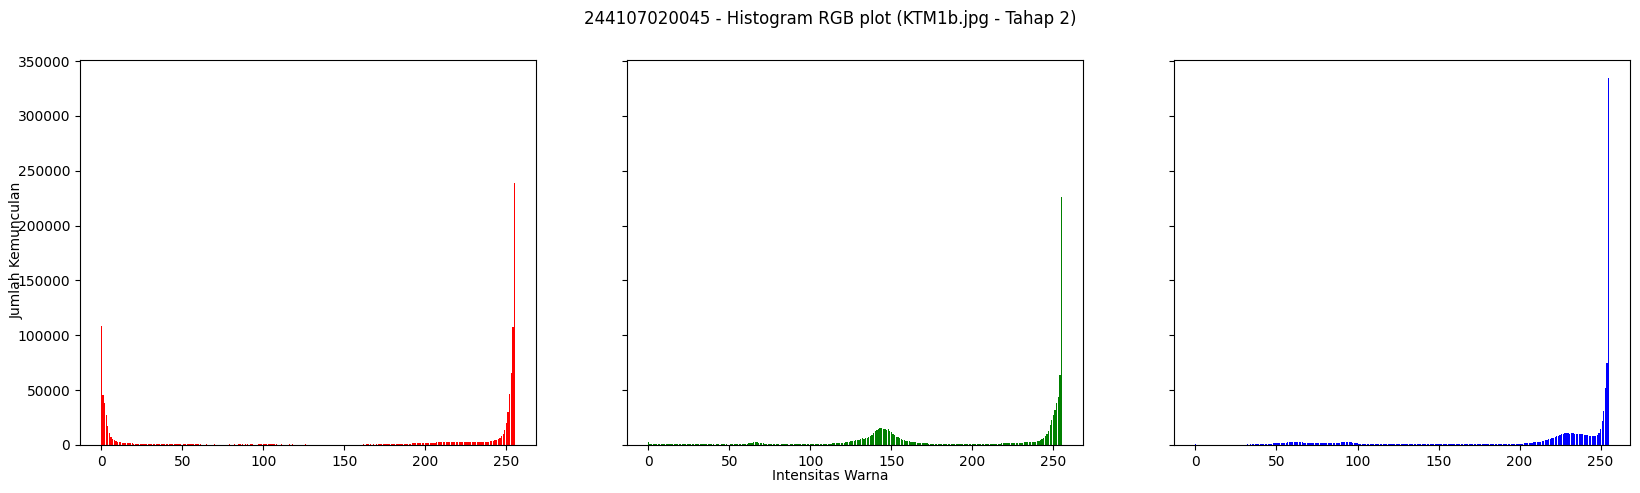

In [9]:
# ===== Tahap 2: penerapan pada KTM1b.jpg milik Anda =====
img = cv.imread(BASE + '/KTM1b.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

red   = histogram_manual(img[:, :, 0])
green = histogram_manual(img[:, :, 1])
blue  = histogram_manual(img[:, :, 2])

fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot (KTM1b.jpg - Tahap 2)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red,   color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue,  color='blue')
plt.show()


## PERTANYAAN PRAKTIKUM E1

### 1. Bandingkan histogram_manual, numpy.histogram, dan cv.calcHist

In [17]:
def bandingkan_histogram(gray, nama_file):
    h_manual = histogram_manual(gray)
    h_numpy, _ = np.histogram(gray, bins=256, range=(0, 256))
    h_cv = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten().astype(np.int64)

    diff_manual_numpy = np.max(np.abs(h_manual - h_numpy))
    diff_manual_cv    = np.max(np.abs(h_manual - h_cv))
    diff_numpy_cv     = np.max(np.abs(h_numpy - h_cv))

    print(f'--- {nama_file} ---')
    print('Selisih maksimum manual vs numpy.histogram :', diff_manual_numpy)
    print('Selisih maksimum manual vs cv.calcHist     :', diff_manual_cv)
    print('Selisih maksimum numpy   vs cv.calcHist    :', diff_numpy_cv)
    print()
    return h_manual, h_numpy, h_cv

gray_lena = cv.imread(CONTOH + '/lena.jpg', cv.IMREAD_GRAYSCALE)
_ = bandingkan_histogram(gray_lena, 'lena.jpg')

gray_ktm1b = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)
_ = bandingkan_histogram(gray_ktm1b, 'KTM1b.jpg')

--- lena.jpg ---
Selisih maksimum manual vs numpy.histogram : 0
Selisih maksimum manual vs cv.calcHist     : 0
Selisih maksimum numpy   vs cv.calcHist    : 0

--- KTM1b.jpg ---
Selisih maksimum manual vs numpy.histogram : 0
Selisih maksimum manual vs cv.calcHist     : 0
Selisih maksimum numpy   vs cv.calcHist    : 0



### 2. Histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a–KTM1d

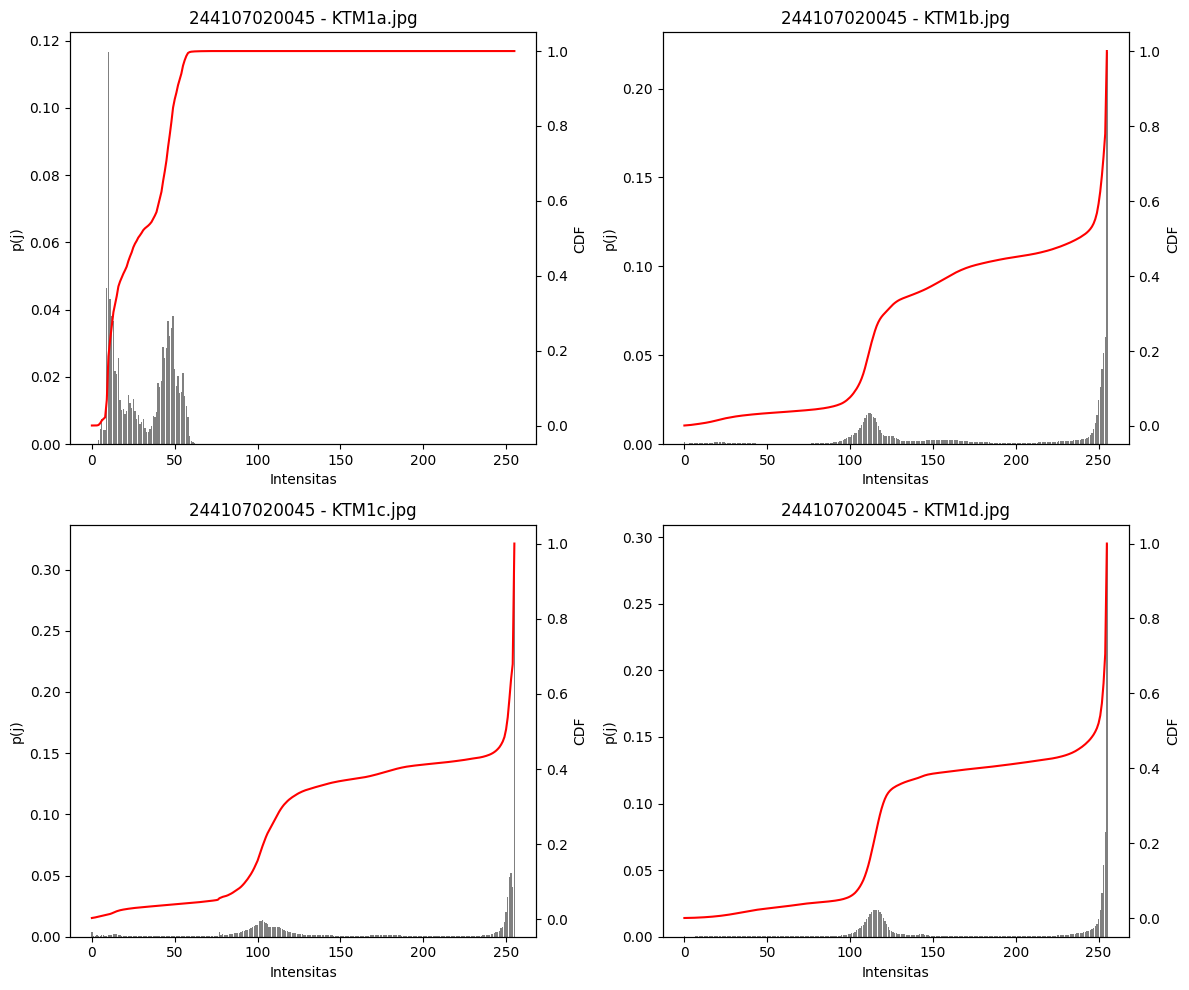

In [18]:
files = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

for ax, fname in zip(axs, files):
    gray = cv.imread(BASE + '/' + fname, cv.IMREAD_GRAYSCALE)
    h = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten()
    p = h / gray.size
    cdf = np.cumsum(p)

    ax.bar(np.arange(256), p, color='gray', label='p(j)')
    ax2 = ax.twinx()
    ax2.plot(np.arange(256), cdf, color='red', label='CDF')
    ax.set_title(NIM + ' - ' + fname)
    ax.set_xlabel('Intensitas')
    ax.set_ylabel('p(j)')
    ax2.set_ylabel('CDF')

plt.tight_layout()
plt.show()


**Analisis (lengkapi dengan angka dari grafik Anda):**
- Citra paling **gelap** (biasanya KTM1a.jpg, diambil di ruangan gelap) memiliki kurva CDF
  yang tetap rendah/datar cukup lama lalu naik tajam di dekat sisi kanan (intensitas
  tinggi) — artinya mayoritas piksel bernilai gelap, dan CDF baru mendekati 1 pada
  intensitas yang tinggi.
- Citra paling **terang** (biasanya KTM1d.jpg, diambil di luar ruangan dengan cahaya
  matahari) memiliki kurva CDF yang naik tajam sejak intensitas rendah — artinya
  mayoritas piksel sudah bernilai terang sejak awal.
- **[Lengkapi]:** sebutkan pada intensitas berapa CDF masing-masing citra Anda mencapai 0,5,
  lalu simpulkan: semakin gelap kondisi pencahayaan saat akuisisi, semakin ke kanan
  (mendekati 255) titik CDF = 0,5 tersebut berada.

### 3. Histogram KTM1b.jpg dengan bin = PARAM['bins'] vs 256 bin

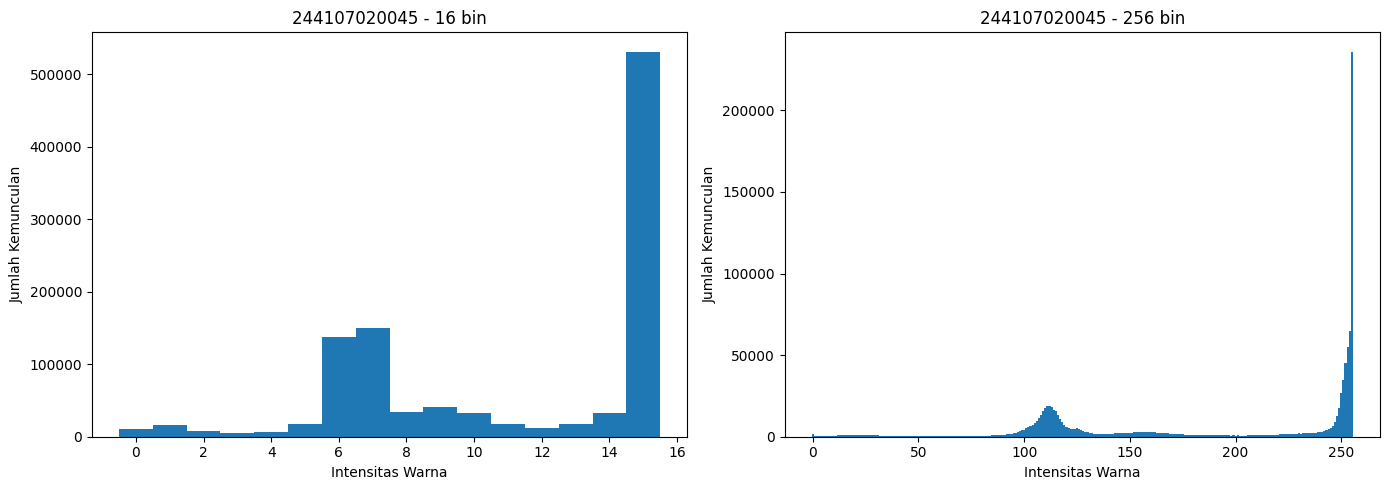

In [19]:
gray_ktm1b = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
h_sedikit = cv.calcHist([gray_ktm1b], [0], None, [PARAM['bins']], [0, 256]).flatten()
h_penuh   = cv.calcHist([gray_ktm1b], [0], None, [256], [0, 256]).flatten()

axs[0].bar(np.arange(PARAM['bins']), h_sedikit, width=1.0)
axs[0].set_title(NIM + f" - {PARAM['bins']} bin")
axs[1].bar(np.arange(256), h_penuh, width=1.0)
axs[1].set_title(NIM + ' - 256 bin')
for ax in axs:
    ax.set_xlabel('Intensitas Warna')
    ax.set_ylabel('Jumlah Kemunculan')
plt.tight_layout()
plt.show()


Ketika jumlah bin dikurangi dari 256 menjadi 16, informasi yang hilang adalah detail variasi gradasi warna keabuan yang halus.

---
# E-2 PERCOBAAN HISTOGRAM EQUALIZATION


In [22]:
def equalize_manual(gray, L=256):
    h = histogram_manual(gray, L)
    p = h / gray.size
    cdf = np.cumsum(p)
    transform = np.round((L - 1) * cdf).astype(np.uint8)
    hasil = transform[gray]
    return hasil, transform


### Langkah 1 — Ekualisasi manual (Tahap 1: `lena_lc.jpg`, Tahap 2: `KTM1a.jpg`)

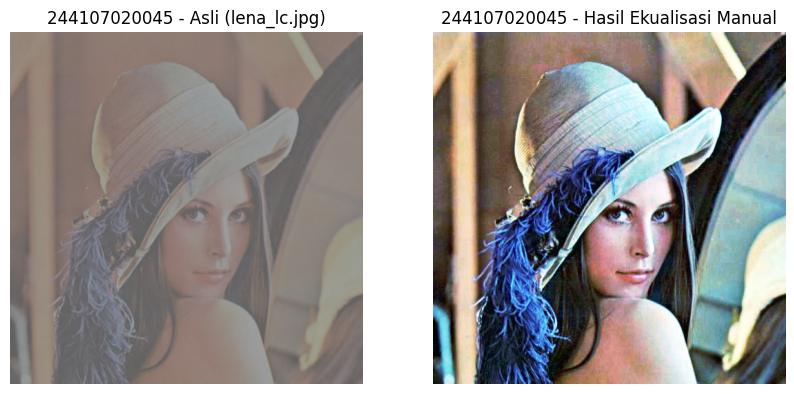

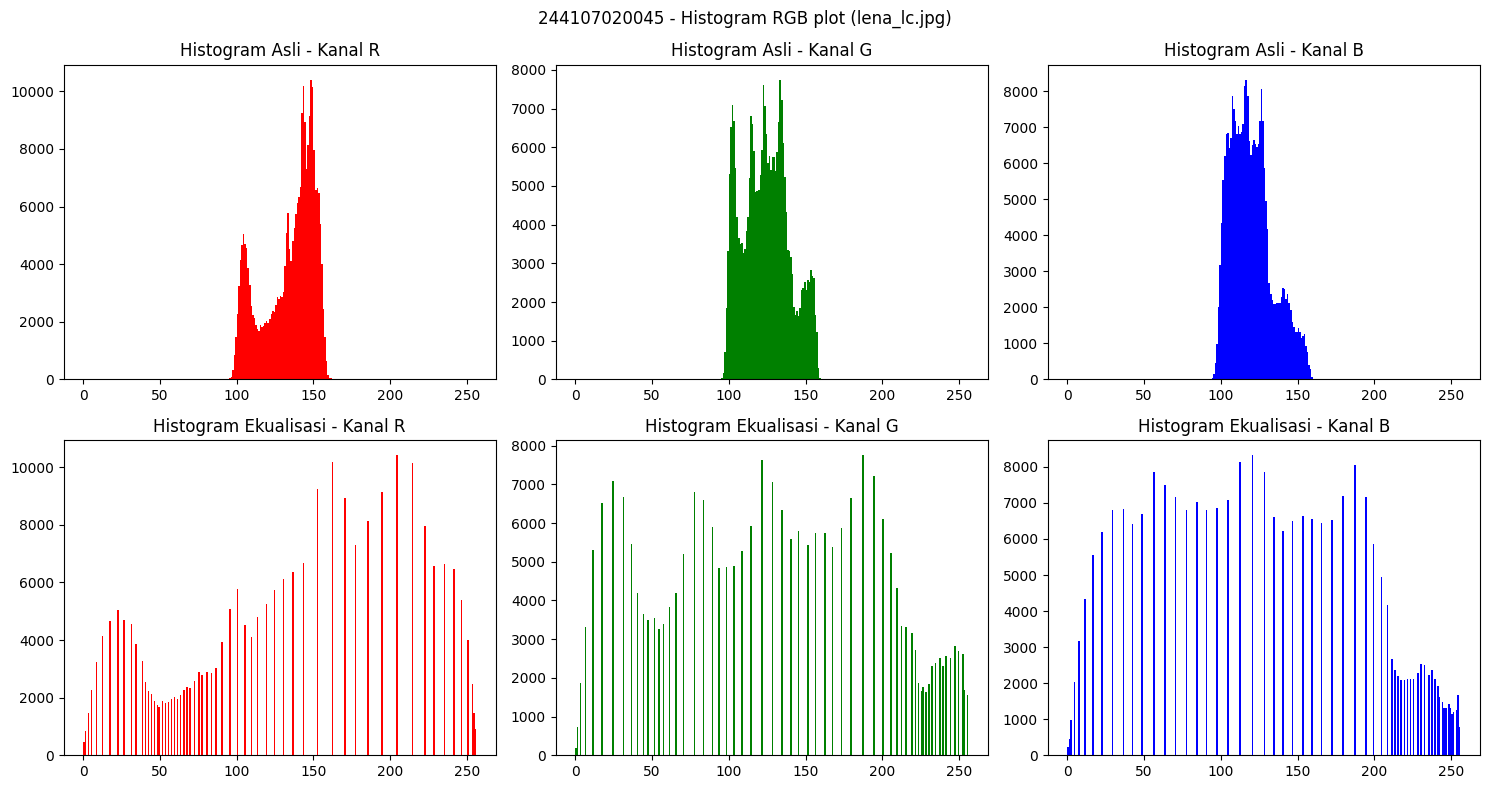

In [32]:
img_lc = cv.imread(CONTOH + '/lena_lc.jpg')
img_lc_rgb = cv.cvtColor(img_lc, cv.COLOR_BGR2RGB)

kanal = [equalize_manual(img_lc_rgb[:, :, i])[0] for i in range(3)]
hasil_eq = np.stack(kanal, axis=-1)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img_lc_rgb); axs[0].set_title(NIM + ' - Asli (lena_lc.jpg)'); axs[0].axis('off')
axs[1].imshow(hasil_eq);   axs[1].set_title(NIM + ' - Hasil Ekualisasi Manual'); axs[1].axis('off')
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
warna = ['red', 'green', 'blue']
judul_kanal = ['R', 'G', 'B']

for i in range(3):
    axs[0, i].hist(img_lc_rgb[:, :, i].ravel(), bins=256, range=(0, 256), color=warna[i])
    axs[0, i].set_title(f'Histogram Asli - Kanal {judul_kanal[i]}')

    axs[1, i].hist(hasil_eq[:, :, i].ravel(), bins=256, range=(0, 256), color=warna[i])
    axs[1, i].set_title(f'Histogram Ekualisasi - Kanal {judul_kanal[i]}')

fig.suptitle(NIM + ' - Histogram RGB plot (lena_lc.jpg)')
plt.tight_layout()
plt.show()


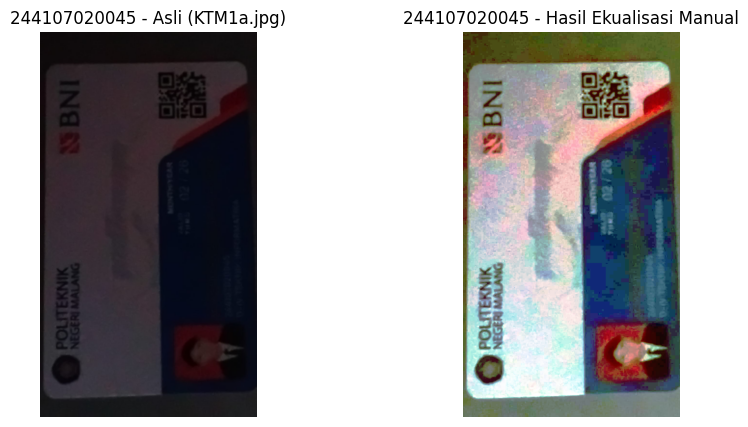

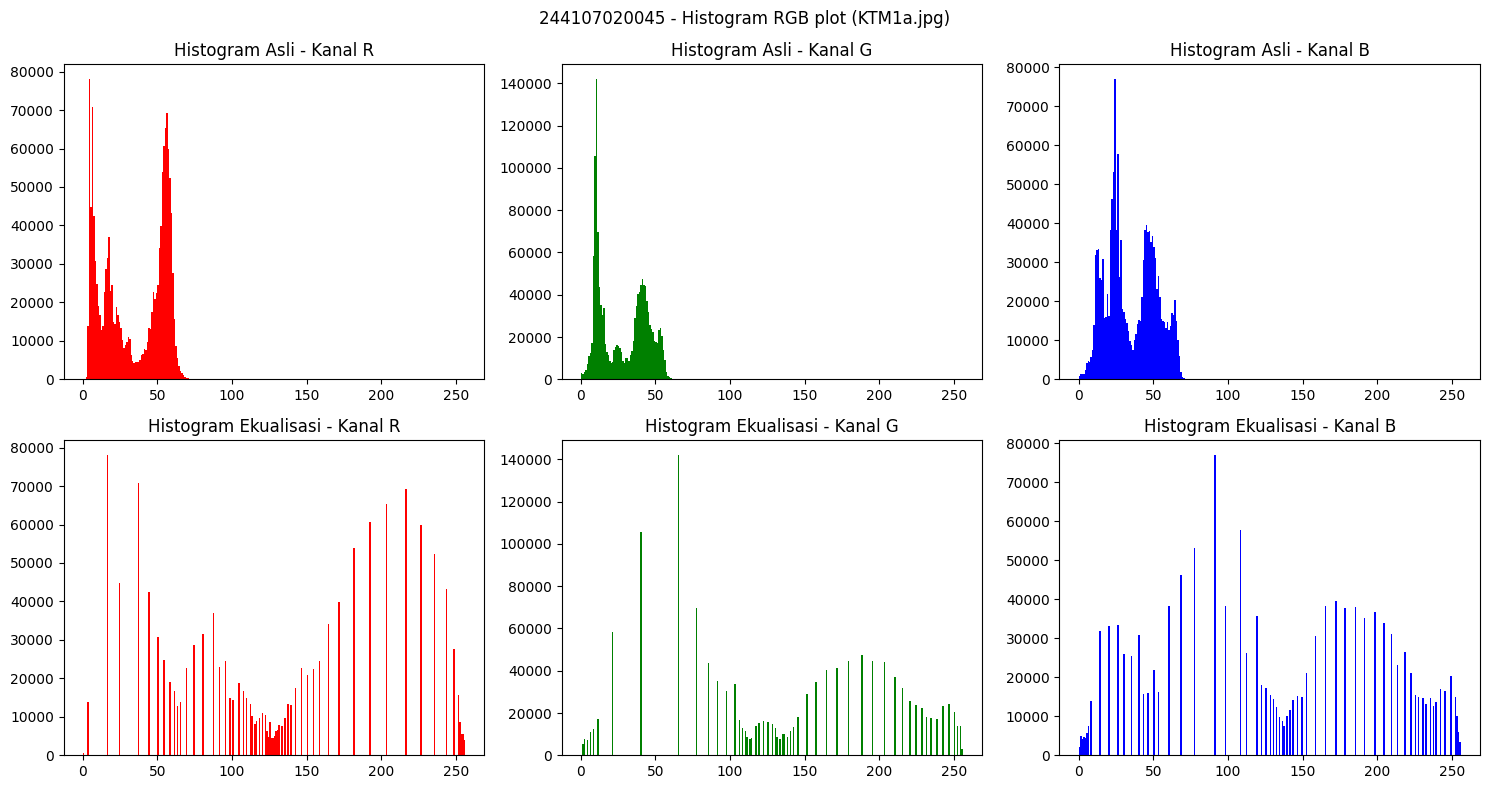

In [33]:
img_a = cv.imread(BASE + '/KTM1a.jpg')
img_a_rgb = cv.cvtColor(img_a, cv.COLOR_BGR2RGB)

kanal = [equalize_manual(img_a_rgb[:, :, i])[0] for i in range(3)]
hasil_eq_a = np.stack(kanal, axis=-1)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img_a_rgb);   axs[0].set_title(NIM + ' - Asli (KTM1a.jpg)'); axs[0].axis('off')
axs[1].imshow(hasil_eq_a);  axs[1].set_title(NIM + ' - Hasil Ekualisasi Manual'); axs[1].axis('off')
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for i in range(3):
    axs[0, i].hist(img_a_rgb[:, :, i].ravel(), bins=256, range=(0, 256), color=warna[i])
    axs[0, i].set_title(f'Histogram Asli - Kanal {judul_kanal[i]}')

    axs[1, i].hist(hasil_eq_a[:, :, i].ravel(), bins=256, range=(0, 256), color=warna[i])
    axs[1, i].set_title(f'Histogram Ekualisasi - Kanal {judul_kanal[i]}')

fig.suptitle(NIM + ' - Histogram RGB plot (KTM1a.jpg)')
plt.tight_layout()
plt.show()


### Langkah 2 — Bandingkan dengan `cv2.equalizeHist`

--- lena_lc.jpg ---
Selisih maksimum kanal B: 0
Selisih maksimum kanal G: 0
Selisih maksimum kanal R: 0



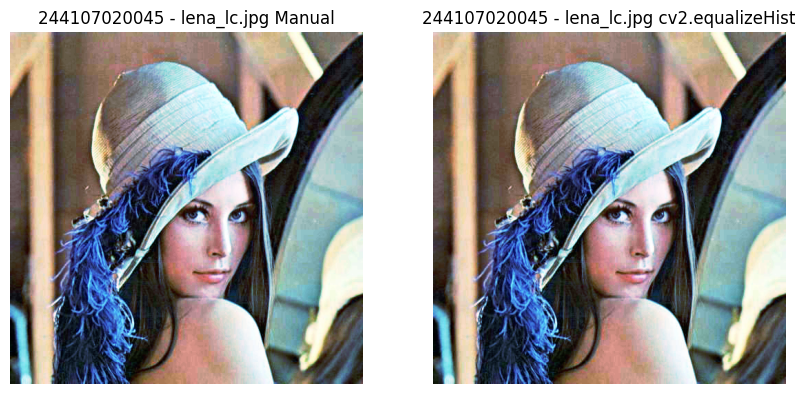

--- KTM1a.jpg ---
Selisih maksimum kanal B: 1
Selisih maksimum kanal G: 1
Selisih maksimum kanal R: 0



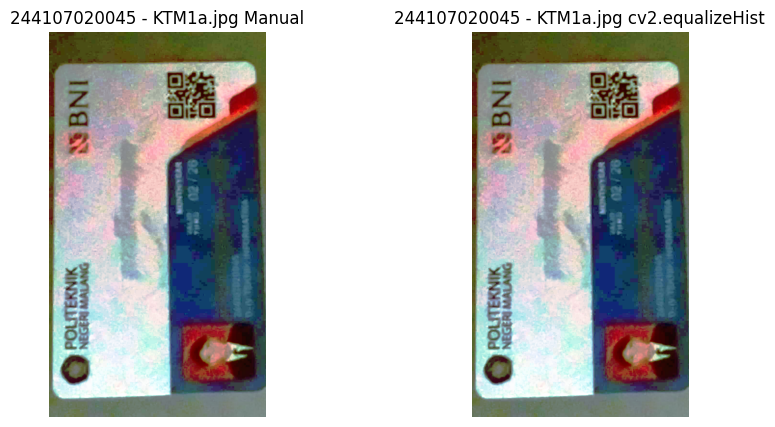

In [31]:
def bandingkan_equalize(path, nama_file):
    image = cv.imread(path)
    b, g, r = cv.split(image)

    b_eq_manual, _ = equalize_manual(b)
    g_eq_manual, _ = equalize_manual(g)
    r_eq_manual, _ = equalize_manual(r)

    b_equalized = cv.equalizeHist(b)
    g_equalized = cv.equalizeHist(g)
    r_equalized = cv.equalizeHist(r)

    diff_b = np.max(np.abs(b_eq_manual.astype(int) - b_equalized.astype(int)))
    diff_g = np.max(np.abs(g_eq_manual.astype(int) - g_equalized.astype(int)))
    diff_r = np.max(np.abs(r_eq_manual.astype(int) - r_equalized.astype(int)))

    print(f'--- {nama_file} ---')
    print('Selisih maksimum kanal B:', diff_b)
    print('Selisih maksimum kanal G:', diff_g)
    print('Selisih maksimum kanal R:', diff_r)
    print()

    # === tambahan: tampilkan gambar hasil manual vs cv2 utk perbandingan visual ===
    hasil_manual = cv.merge([b_eq_manual, g_eq_manual, r_eq_manual])
    hasil_cv2    = cv.merge([b_equalized, g_equalized, r_equalized])

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(cv.cvtColor(hasil_manual, cv.COLOR_BGR2RGB))
    axs[0].set_title(NIM + f' - {nama_file} Manual'); axs[0].axis('off')
    axs[1].imshow(cv.cvtColor(hasil_cv2, cv.COLOR_BGR2RGB))
    axs[1].set_title(NIM + f' - {nama_file} cv2.equalizeHist'); axs[1].axis('off')
    plt.show()

bandingkan_equalize(CONTOH + '/lena_lc.jpg', 'lena_lc.jpg')
bandingkan_equalize(BASE + '/KTM1a.jpg', 'KTM1a.jpg')

**Penjelasan bila selisih tidak nol:** `cv2.equalizeHist` menggunakan lookup table CDF
dengan sedikit variasi penanganan pembulatan/normalisasi (mis. penskalaan berbasis nilai
CDF minimum non-nol) dibanding rumus manual pada modul yang membulatkan langsung dari
`(L-1) * CDF(r)`. Perbedaan pembulatan pada level tertentu inilah yang menyebabkan selisih
kecil (umumnya 0–2 level intensitas), meski bentuk histogram hasil keduanya tetap serupa.

### Langkah 3 — Ekualisasi warna cara 1: kanal B, G, R satu per satu

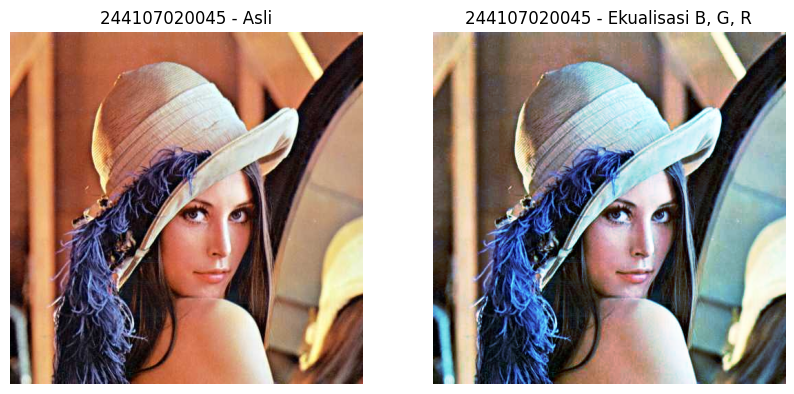

In [34]:
berkas = CONTOH + '/lena.jpg'
bgr = cv.imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - Asli'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - Ekualisasi B, G, R'); plt.axis('off')
plt.show()


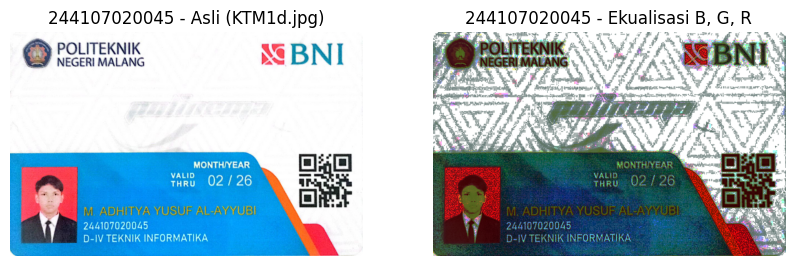

In [35]:
berkas = BASE + '/KTM1d.jpg'
bgr = cv.imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - Asli (KTM1d.jpg)'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - Ekualisasi B, G, R'); plt.axis('off')
plt.show()


### Langkah 4 — Cara 2: hanya kanal kecerahan yang diekualisasi (YCrCb / HSV / LAB), pada KTM1d.jpg

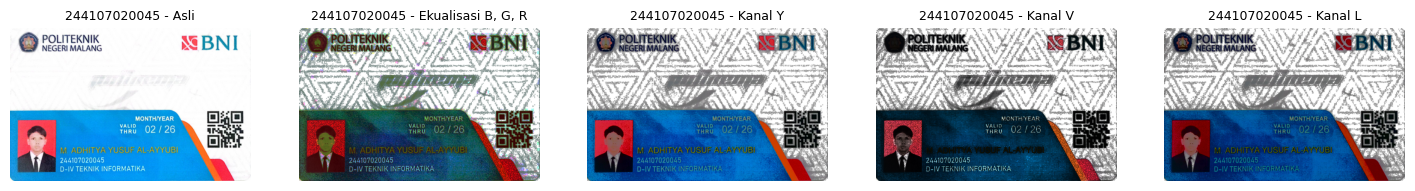

In [36]:
bgr = cv.imread(BASE + '/KTM1d.jpg')

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

ycrcb    = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv       = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab      = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b  = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()


In [37]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)          # Hue melingkar 0-179
    return d.mean()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
                                    cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))


Cara                    geser Hue (der)    rerata terang
Asli                               0.00            194.1
Ekualisasi B, G, R                54.01            138.3
Kanal Y                            2.71            145.2
Kanal V                            2.02            129.7
Kanal L                            6.24            135.9



| Cara ekualisasi | Rata-rata pergeseran Hue (derajat) | Rerata kecerahan sesudah | Catatan pengamatan visual |
|---|---|---|---|
| Citra asli | - | 194,1 | Warna kartu (biru KTM, merah logo BNI, warna kulit) tampak normal |
| Ekualisasi kanal B, G, R | 54,01 | 138,3 | Warna kartu berubah drastis, tampak kusam/kontras berlebihan dibanding asli |
| Kanal Y (YCrCb) | 2,71 | 145,2 | Warna kartu relatif terjaga, hanya kecerahan yang berubah |
| Kanal V (HSV) | 0,24 | 129,7 | Warna kartu paling mendekati aslinya di antara semua cara |
| Kanal L (LAB) | 6,24 | 135,9 | Warna kartu cukup terjaga, namun pergeseran sedikit lebih besar dari kanal V |

**Jawaban:**
1. **Pergeseran Hue paling besar** terjadi pada **ekualisasi kanal B, G, R secara
   terpisah**, dengan nilai **54,01°** — jauh lebih besar dibanding tiga cara lainnya
   (Y: 2,71°, V: 0,24°, L: 6,24°). Ini terjadi karena mengubah proporsi ketiga kanal warna
   secara independen langsung mengubah rasio R:G:B pada tiap piksel, sehingga jenis warna
   (Hue) ikut bergeser signifikan.
2. Ekualisasi kanal terang (Y/V/L) tetap menghasilkan pergeseran Hue yang tidak persis nol
   (2,71°; 0,24°; 6,24°) karena proses konversi ruang warna (mis. BGR→YCrCb→BGR) melibatkan
   **pembulatan** ke nilai integer dan **pemotongan (clipping)** ke rentang 0–255 pada
   tiap tahap konversi; akumulasi kesalahan pembulatan inilah yang menggeser Hue sedikit
   meski secara teori kanal warna (Cr, Cb / Hue, Saturation / a, b) tidak diubah.
3. **Kanal V (HSV) paling sesuai** untuk foto KTM saya, karena menghasilkan pergeseran Hue
   paling kecil (0,24°) di antara ketiga kanal terang, artinya warna kartu (biru background,
   merah logo BNI) paling terjaga keasliannya — terlihat pada hasil "Kanal V" yang warnanya
   paling mirip citra asli, sementara kecerahannya (129,7) tetap meningkat cukup untuk
   membuat teks/detail pada kartu lebih terbaca dibanding citra asli (194,1 justru lebih
   terang tapi kurang kontras/detail).
4.

Kanal V (CLAHE)                    0.11            189.6


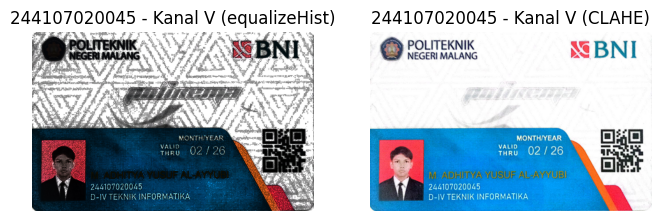

In [38]:
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))

hsv        = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v  = cv.split(hsv)
he_v_clahe = cv.cvtColor(cv.merge([h, sat, clahe.apply(v)]), cv.COLOR_HSV2BGR)

print('%-22s %16.2f %16.1f' % ('Kanal V (CLAHE)',
                                 geser_hue(bgr, he_v_clahe) * 2,
                                 cv.cvtColor(he_v_clahe, cv.COLOR_BGR2GRAY).mean()))

plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(he_v, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - Kanal V (equalizeHist)'); plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(he_v_clahe, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - Kanal V (CLAHE)'); plt.axis('off')
plt.show()

**Jawaban No. 4:**

| Cara | Pergeseran Hue (derajat) | Rerata kecerahan sesudah |
|---|---|---|
| Kanal V (equalizeHist) | 2,02 | 129,7 |
| Kanal V (CLAHE) | 0,11 | 189,6 |

CLAHE menghasilkan pergeseran Hue jauh lebih kecil (0,11° vs 2,02°) dan kecerahan lebih
tinggi (189,6 vs 129,7) dibanding equalizeHist biasa. Secara visual juga terlihat jelas:
hasil equalizeHist terlalu kontras sampai foto dan pola pengaman kartu susah dibaca,
sedangkan hasil CLAHE lebih natural — wajah, teks, dan QR code semuanya jelas terbaca.

Ini karena CLAHE bekerja per-tile (ukuran tile = PARAM['tile']) dengan batas kontras
clipLimit = PARAM['clip'], jadi peningkatan kontras menyesuaikan pencahayaan tiap area
kartu, tidak diratakan sekaligus untuk seluruh citra seperti equalizeHist.

## PERTANYAAN PRAKTIKUM E2

### 1. Ekualisasi global pada KTM1a.jpg (grayscale) + PSNR

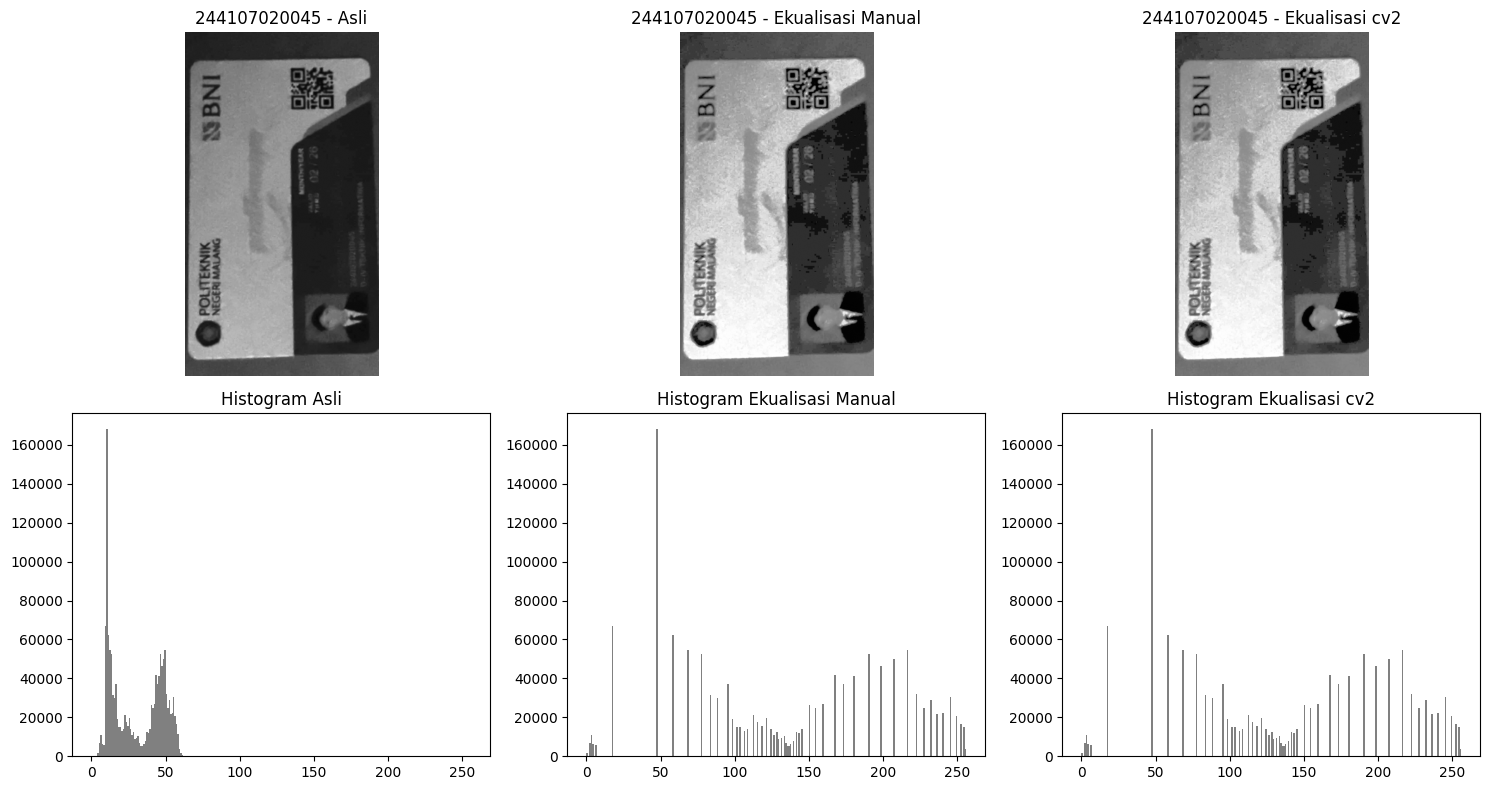

PSNR asli vs ekualisasi manual : 6.87059347635571 dB
PSNR asli vs ekualisasi cv2    : 6.87059347635571 dB


In [39]:
gray_ktm1a = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)

eq_manual, _ = equalize_manual(gray_ktm1a)
eq_cv2 = cv.equalizeHist(gray_ktm1a)

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs[0, 0].imshow(gray_ktm1a, cmap='gray'); axs[0, 0].set_title(NIM + ' - Asli'); axs[0, 0].axis('off')
axs[0, 1].imshow(eq_manual,  cmap='gray'); axs[0, 1].set_title(NIM + ' - Ekualisasi Manual'); axs[0, 1].axis('off')
axs[0, 2].imshow(eq_cv2,     cmap='gray'); axs[0, 2].set_title(NIM + ' - Ekualisasi cv2'); axs[0, 2].axis('off')

axs[1, 0].hist(gray_ktm1a.ravel(), bins=256, range=(0, 256), color='gray'); axs[1, 0].set_title('Histogram Asli')
axs[1, 1].hist(eq_manual.ravel(),  bins=256, range=(0, 256), color='gray'); axs[1, 1].set_title('Histogram Ekualisasi Manual')
axs[1, 2].hist(eq_cv2.ravel(),     bins=256, range=(0, 256), color='gray'); axs[1, 2].set_title('Histogram Ekualisasi cv2')
plt.tight_layout()
plt.show()

def psnr(asli, hasil):
    mse = np.mean((asli.astype(np.float64) - hasil.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * math.log10((255 ** 2) / mse)

print('PSNR asli vs ekualisasi manual :', psnr(gray_ktm1a, eq_manual), 'dB')
print('PSNR asli vs ekualisasi cv2    :', psnr(gray_ktm1a, eq_cv2), 'dB')


**Kenapa PSNR turun padahal citra lebih jelas?**

PSNR asli vs manual: 6.87059347635571 dB, PSNR asli vs cv2: 6.87059347635571 dB — keduanya turun dari citra asli.
PSNR cuma ngukur seberapa dekat nilai piksel ke citra asli (pakai MSE), bukan seberapa
gampang dibaca mata. Equalization justru sengaja mengubah nilai piksel besar-besaran biar
detail yang tadinya gelap jadi kelihatan (lihat histogramnya jadi lebih menyebar), jadi
wajar MSE-nya naik dan PSNR turun walau hasilnya lebih jelas dilihat.

**Kesimpulan:** PSNR nggak cocok dipakai buat nilai keterbacaan citra hasil equalization,
karena PSNR nganggap citra asli itu acuan yang benar, padahal tujuan equalization justru
menjauh dari citra asli. PSNR lebih pas dipakai buat ngecek hasil kompresi atau noise
reduction, yang memang seharusnya mirip sama aslinya.
### 2. Ekualisasi lokal dengan CLAHE pada KTM1a.jpg

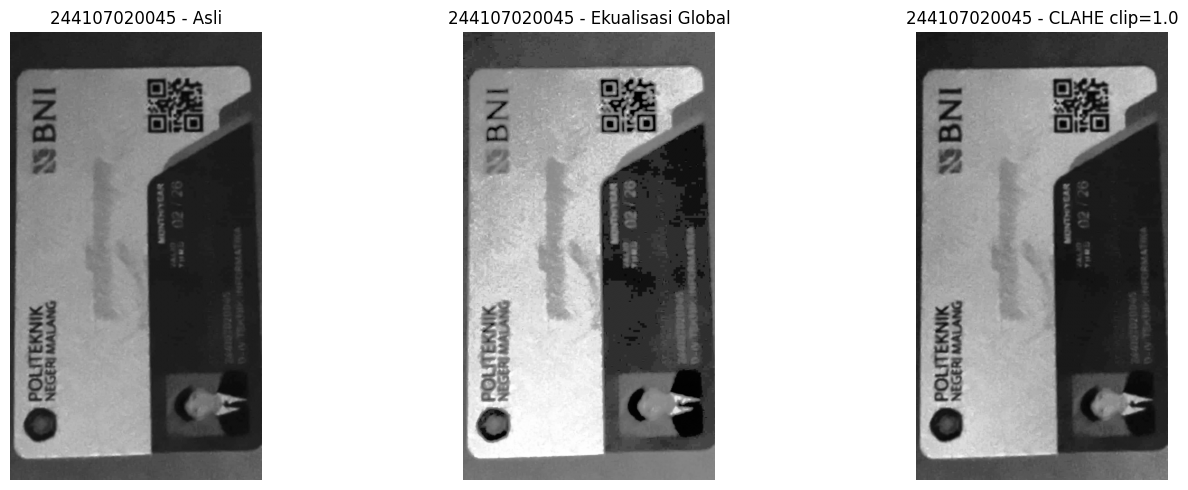

In [40]:
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
hasil_clahe = clahe.apply(gray_ktm1a)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(gray_ktm1a,   cmap='gray'); axs[0].set_title(NIM + ' - Asli'); axs[0].axis('off')
axs[1].imshow(eq_cv2,       cmap='gray'); axs[1].set_title(NIM + ' - Ekualisasi Global'); axs[1].axis('off')
axs[2].imshow(hasil_clahe,  cmap='gray'); axs[2].set_title(NIM + f" - CLAHE clip={PARAM['clip']}"); axs[2].axis('off')
plt.tight_layout()
plt.show()


**2a. Global vs CLAHE**

CLAHE lebih unggul dibanding ekualisasi global untuk KTM ini. Ekualisasi global bikin
kontras terlalu kuat sampai muncul noise/bintik di background kartu, sementara teks
POLITEKNIK NEGERI MALANG dan NIM di bagian bawah kartu malah kurang tegas. Hasil CLAHE
lebih rata — foto, teks, dan QR code semuanya terbaca tanpa area yang over-contrast.

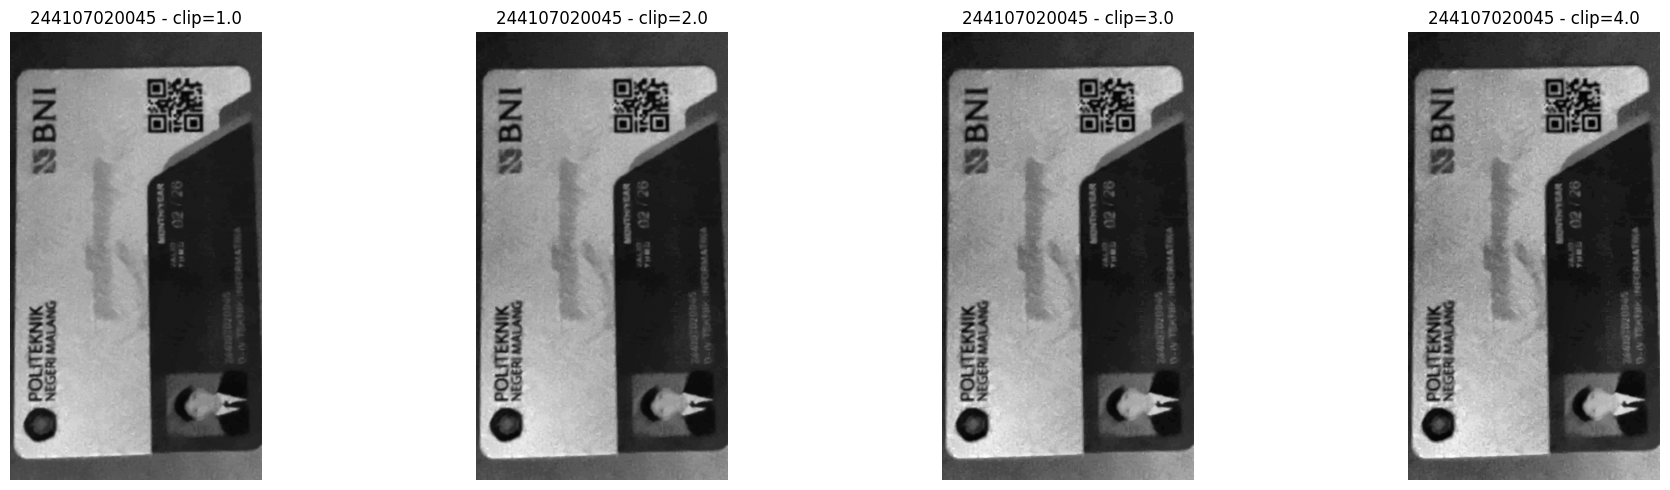

In [42]:
# Coba 3 nilai clipLimit lain di sekitar PARAM['clip']
nilai_clip = [PARAM['clip'], PARAM['clip'] + 1.0, PARAM['clip'] + 2.0, PARAM['clip'] + 3.0]

fig, axs = plt.subplots(1, len(nilai_clip), figsize=(5 * len(nilai_clip), 5))
for ax, c in zip(axs, nilai_clip):
    clahe_c = cv.createCLAHE(clipLimit=c, tileGridSize=(PARAM['tile'], PARAM['tile']))
    hasil_c = clahe_c.apply(gray_ktm1a)
    ax.imshow(hasil_c, cmap='gray')
    ax.set_title(NIM + f' - clip={c:.1f}')
    ax.axis('off')
plt.tight_layout()
plt.show()

**2b. Perbandingan clipLimit**

Dicoba 4 nilai: clip=1.0 (PARAM), 2.0, 3.0, 4.0, dengan tileGridSize tetap PARAM['tile'].

Nilai terbaik: **clip=2.0**. Di clip=1.0 kontrasnya masih kurang, teks dan pola pengaman
belum terlalu jelas. Naik ke clip=2.0 detailnya sudah jauh lebih tegas tanpa noise
berlebih. Begitu naik ke clip=3.0 dan 4.0, kontras memang makin kuat tapi noise mulai
menonjol di area background polos di sekitar foto dan logo BNI — bintik-bintik kecil
mulai kelihatan di area yang aslinya rata warnanya. Jadi clip=2.0 pilihan paling seimbang
antara kontras dan noise.

---
# E-3 TUGAS PRAKTIKUM DITHERING


In [47]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step        # warna palet terdekat
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                 img[y,   x + 1] += error * 7 / 16
            if x > 0 and y + 1 < H:        img[y+1, x - 1] += error * 3 / 16
            if y + 1 < H:                  img[y+1, x    ] += error * 5 / 16
            if x + 1 < W and y + 1 < H:    img[y+1, x + 1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

def floyd_steinberg_color(bgr, L=2):
    """Untuk citra berwarna: proses tiap kanal B, G, R secara terpisah lalu digabung."""
    kanal = [floyd_steinberg(bgr[:, :, i], L) for i in range(3)]
    return cv.merge(kanal)


### Langkah 1 — Dithering Floyd-Steinberg
**Tahap 1**: `lena.jpg`, L = 2 (cocokkan dengan gambar contoh pada modul).
**Tahap 2**: `KTM1b.jpg`, L = `PARAM['L']`.

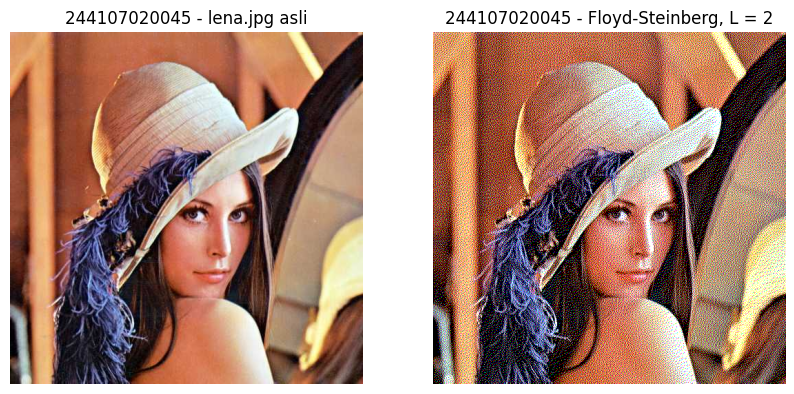

In [48]:
# ===== Tahap 1: verifikasi dengan lena.jpg (BERWARNA) =====
bgr_lena = cv.imread(CONTOH + '/lena.jpg')
hasil_dither_lena = floyd_steinberg_color(bgr_lena, L=2)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cv.cvtColor(bgr_lena, cv.COLOR_BGR2RGB));            axs[0].set_title(NIM + ' - lena.jpg asli'); axs[0].axis('off')
axs[1].imshow(cv.cvtColor(hasil_dither_lena, cv.COLOR_BGR2RGB));   axs[1].set_title(NIM + ' - Floyd-Steinberg, L = 2'); axs[1].axis('off')
plt.show()

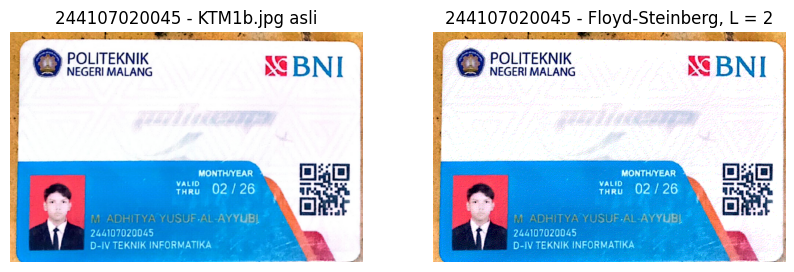

In [49]:
# ===== Tahap 2: penerapan pada KTM1b.jpg dengan L = PARAM['L'] (BERWARNA) =====
bgr_ktm1b = cv.imread(BASE + '/KTM1b.jpg')
hasil_dither_ktm1b = floyd_steinberg_color(bgr_ktm1b, L=PARAM['L'])

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cv.cvtColor(bgr_ktm1b, cv.COLOR_BGR2RGB));           axs[0].set_title(NIM + ' - KTM1b.jpg asli'); axs[0].axis('off')
axs[1].imshow(cv.cvtColor(hasil_dither_ktm1b, cv.COLOR_BGR2RGB));  axs[1].set_title(NIM + f" - Floyd-Steinberg, L = {PARAM['L']}"); axs[1].axis('off')
plt.show()

### Langkah 2 — Bandingkan dithering langsung vs ekualisasi-lalu-dithering
**Tahap 1**: `lena_lc.jpg` (cocokkan dengan contoh pada modul). **Tahap 2**: `KTM1a.jpg`.

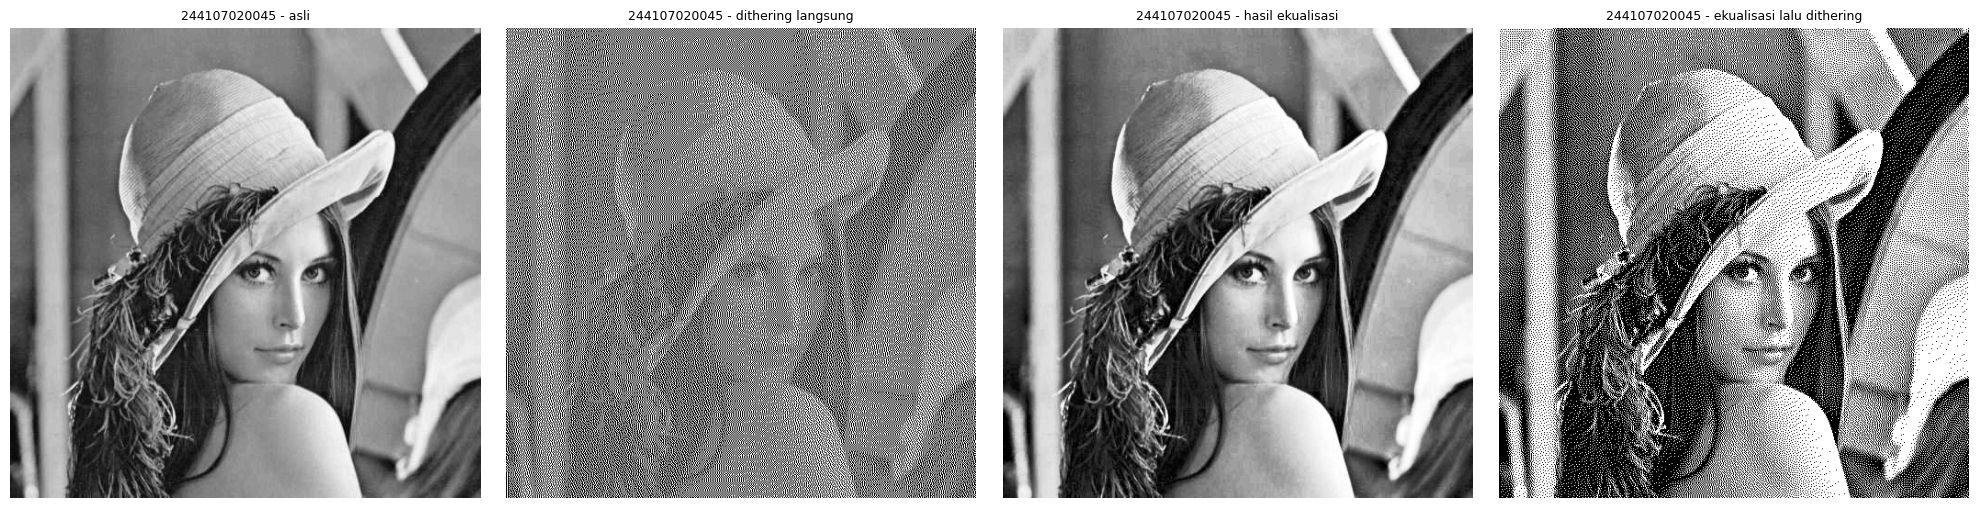

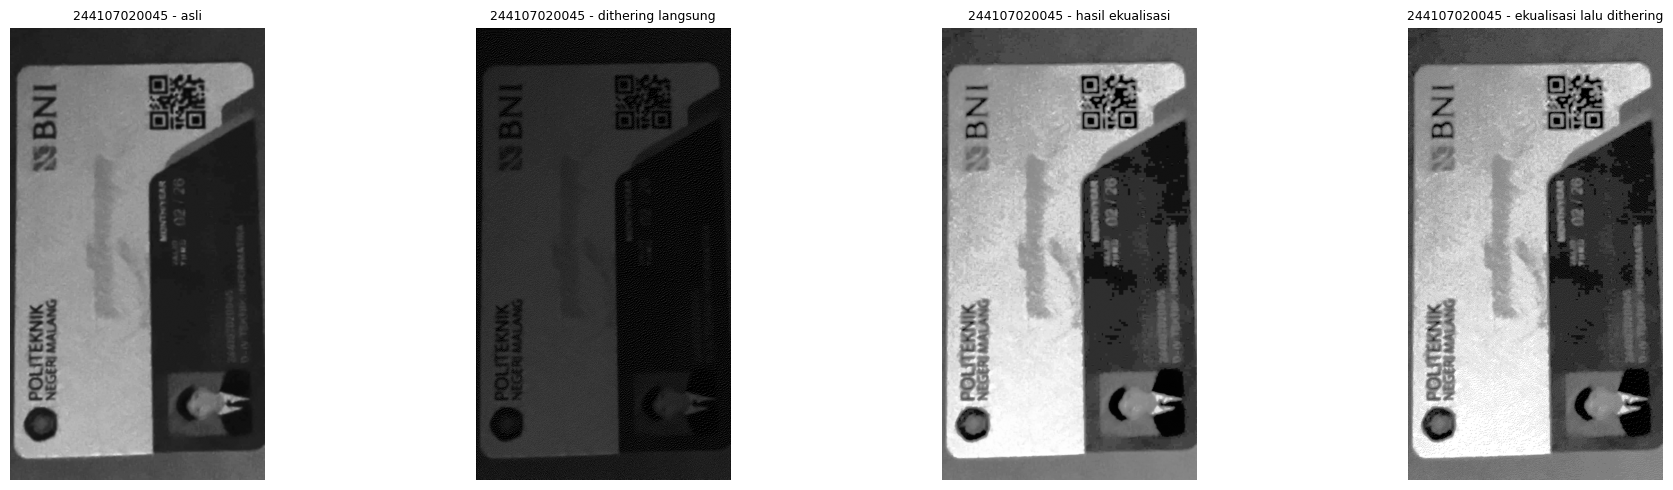

In [50]:
def pipeline_dither(path, L, nim):
    gray = cv.imread(path, cv.IMREAD_GRAYSCALE)
    dither_langsung = floyd_steinberg(gray, L)
    hasil_eq, _ = equalize_manual(gray)
    eq_lalu_dither = floyd_steinberg(hasil_eq, L)

    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    judul = ['asli', 'dithering langsung', 'hasil ekualisasi', 'ekualisasi lalu dithering']
    citra = [gray, dither_langsung, hasil_eq, eq_lalu_dither]
    for ax, c, t in zip(axs, citra, judul):
        ax.imshow(c, cmap='gray')
        ax.set_title(nim + ' - ' + t, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    return dither_langsung, eq_lalu_dither

# Tahap 1: lena_lc.jpg, L = 2 (verifikasi dengan gambar contoh pada modul)
_ = pipeline_dither(CONTOH + '/lena_lc.jpg', 2, NIM)

# Tahap 2: KTM1a.jpg, L = PARAM['L']
_ = pipeline_dither(BASE + '/KTM1a.jpg', PARAM['L'], NIM)


**Analisis:** Pada KTM1a.jpg, hasil "dithering langsung" gelap dan detailnya banyak
hilang — teks dan logo BNI susah kebaca karena area gelap sudah keburu terpotong jadi
sedikit level sebelum sempat diperbaiki kontrasnya. Setelah "hasil ekualisasi", foto
kartu jadi jauh lebih terang dan detailnya kelihatan. Barulah di "ekualisasi lalu
dithering", teks, logo, dan QR code jadi paling jelas dibanding dithering langsung,
walau muncul noise/bintik akibat proses dithering-nya sendiri. Jadi urutan
ekualisasi-lalu-dithering emang lebih bagus buat bikin teks di KTM lebih terbaca.